# Implementação 1 - AA204 # 

## Referências: 
- Aerodynamics of Wind Turbines - Hansen  
- General Momemntum Theroy - Sorensen
- Viterna, L. A., & Corrigan, R. D. (1982). Fixed pitch rotor performance of large horizontal axis 
wind turbines. Large Horizontal-Axis Wind Turbines.  
- Investigating Three-Dimensional
and Rotational Effects on Wind
Turbine Blades by Means of a
Quasi-3D Navier-Stokes Solver - Hansen
- Notas e Slides de Aula - AA-204 

In [167]:
import numpy as np  
import matplotlib.pyplot as plt 
import scipy as sp 
import pandas as pd

In [168]:
#Dados de entrada de Projeto 
TSR = 6      #Tip Speed Ratio 
V_0 = 10     #Velocidade do vento (m/s) 
R = 20      #Raio da pá (m)  
R_cubo = 4   #Raio do cubo (m) 
B = 4     #Número de pás da turbina eólica  
rho = 1.225    #Densidade do ar (kg/m³) 
omega = TSR * V_0 / R   #Velocidade angular da turbina (rad/s) 
r_cubo_R = R_cubo / R   #posição normalizada do cubo (r_cubo/R)

In [169]:
#calcular o Reynolds inicial  
Cl_design = 1.0 #Manwell, McGowan & Rogers — "Wind Energy Explained: Theory, Design and Application", 2ª ed., Wiley, 2009 
mu = 1.81e-5   #Viscosidade dinâmica do ar (Pa·s, ~15°C)
c = (16 * np.pi * R) / (9 * B * TSR * Cl_design)
V_rel_75 = np.sqrt(V_0**2 + (omega * (0.75 * R))**2)   # velocidade relativa no ponto de 75% do raio (m/s)  
Re = (rho * V_rel_75 * c) / mu   #Reynolds inicial no ponto de 75% do raio   

In [170]:
#Dados de aerofolio (S834) — escolhe o bloco de Reynolds mais próximo do Re do chute inicial

def ler_blocos_aerofolio(caminho):
    """Lê o .txt e separa em blocos (Re, DataFrame com alpha/Cl/Cd)."""
    with open(caminho, 'r') as f:
        linhas = f.readlines()

    blocos = []
    i = 0
    while i < len(linhas):
        if 'Average Reynolds' in linhas[i]:
            Re_bloco = float(linhas[i + 1].strip())
            j = i + 2
            while 'alpha' not in linhas[j]:
                j += 1
            j += 1

            dados = []
            while j < len(linhas):
                linha = linhas[j].strip()
                if not linha:
                    break
                try:
                    partes = linha.split()
                    valores = [float(partes[0]), float(partes[1]), float(partes[2])]
                except ValueError:
                    break   #chegou no rodape
                dados.append(valores)
                j += 1

            blocos.append((Re_bloco, pd.DataFrame(dados, columns=['alpha', 'Cl', 'Cd'])))
            i = j
        else:
            i += 1

    return blocos


def escolher_dados_por_reynolds(caminho, Re_alvo):
    blocos = ler_blocos_aerofolio(caminho)
    Re_disponiveis = np.array([b[0] for b in blocos])
    idx_mais_proximo = np.argmin(np.abs(Re_disponiveis - Re_alvo))

    print(f'Re = {Re_alvo:.0f} , Re disponível: {Re_disponiveis[idx_mais_proximo]:.0f}')
    return blocos[idx_mais_proximo][1]


caminho = r"C:\Users\JVicenteRGD\Documents\Aerodinamica de Asas Rotativas\Dados de Aerofolio\Airfoil_S834.txt"
dados_S834 = escolher_dados_por_reynolds(caminho, Re)

Re = 14520550 , Re disponível: 499497


Ponto ótimo do aerofólio S834 no Reynolds Inicial: Ângulo de ataque = 5.20°, Cl = 0.75, Razão Cl/Cd = 79.47


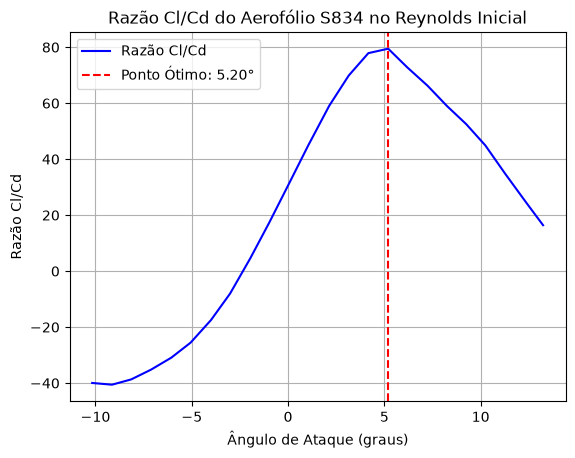

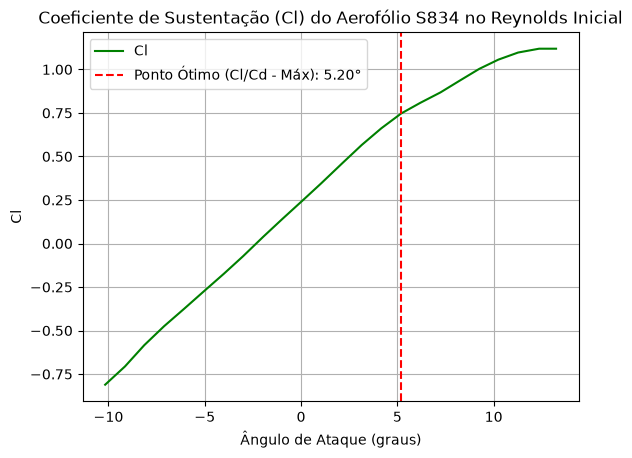

In [171]:
#Aerofolio 
razao_cl_cd = dados_S834['Cl'] / dados_S834['Cd']  # Razão entre os coeficientes de sustentação e arrasto do aerofólio 
id_otimo = razao_cl_cd.idxmax()  # Índice do ponto ótimo (máxima razão Cl/Cd) 
alpha_otimo = dados_S834.loc[id_otimo, 'alpha']  # Ângulo de ataque do ponto ótimo (graus) 
Cl_otimo = dados_S834.loc[id_otimo, 'Cl']  # Coeficiente de sustentação do ponto ótimo   
Cd_min = dados_S834['Cd'].min()   #calcula uma vez, fora do loop
print(f'Ponto ótimo do aerofólio S834 no Reynolds Inicial: Ângulo de ataque = {alpha_otimo:.2f}°, Cl = {Cl_otimo:.2f}, Razão Cl/Cd = {razao_cl_cd[id_otimo]:.2f}')

plt.figure()
plt.plot(dados_S834['alpha'], razao_cl_cd, label='Razão Cl/Cd', color='blue') 
plt.title('Razão Cl/Cd do Aerofólio S834 no Reynolds Inicial')
plt.xlabel('Ângulo de Ataque (graus)')
plt.ylabel('Razão Cl/Cd') 
plt.axvline(x=alpha_otimo, color='red', linestyle='--', label=f'Ponto Ótimo: {alpha_otimo:.2f}°')
plt.legend()
plt.grid() 

plt.figure() 
plt.plot(dados_S834['alpha'], dados_S834['Cl'], label='Cl', color='green')
plt.title('Coeficiente de Sustentação (Cl) do Aerofólio S834 no Reynolds Inicial')
plt.xlabel('Ângulo de Ataque (graus)')
plt.ylabel('Cl')
plt.axvline(x=alpha_otimo, color='red', linestyle='--', label=f'Ponto Ótimo (Cl/Cd - Máx): {alpha_otimo:.2f}°')
plt.legend()
plt.grid() 


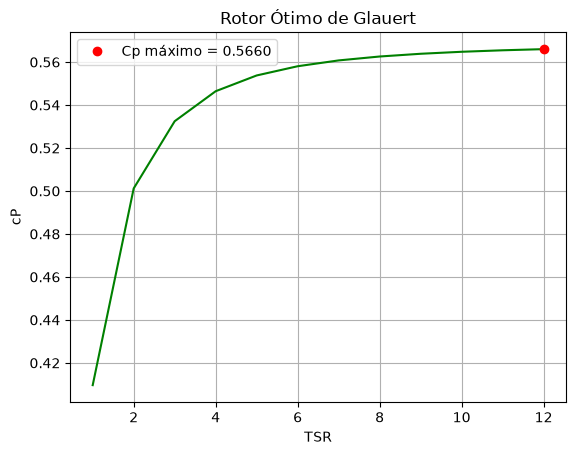

In [172]:
#Implementação do Rotor ótimo de Glauert - Pag. 99 Introduction to Wind Turbine Aerodynamics usando a expressão deduzida 
TSR_lista = np.linspace(1, 12, 12)  #Tip Speed Ratio
Cp_lista = []  
c_Matrix = []  # Matriz para armazenar os valores de corda para cada TSR e r local  
torcao_Matrix = []  # Matriz para armazenar os valores de torção para cada TSR e r local  
sigma_Matrix = []  # Matriz para armazenar os valores de fator de solidez para cada TSR e r local 

for w in range(len(TSR_lista)): #Tem uma expressaõ de deduzida aqui
    x_lista = np.linspace(TSR_lista[w] * r_cubo_R, TSR_lista[w], 500)  # Razão de velocidade local  
    r_R = x_lista / TSR_lista[w] #posição radial normalizada (r/R) 

    sigma_lista = [] 
    c_lista = []   
    phi_lista = [] 
    torcao_lista = []  
    dCp_lista = []  
    
    for z in range(len(x_lista)):  

        coeffs = [16, -24, 9 - 3 * x_lista[z]**2, x_lista[z]**2 - 1]

        roots = np.roots(coeffs)

        a = [r.real for r in roots if abs(r.imag) < 1e-8 and 0.25 < r.real < 1/3][0]

        a_linha = (1 - 3 * a) / (4 * a - 1)

        phi_lista.append(np.arctan2(a_linha * x_lista[z], a))  

        A = a / ( 1 - a)  
        sigma_lista.append(4 * A * (np.sin(phi_lista[z]) ** 2 / (Cl_otimo * np.cos(phi_lista[z]) + dados_S834.loc[id_otimo, 'Cd'] * np.sin(phi_lista[z]))))   # Fator de solidez local da pá          
        c_lista.append(sigma_lista[z] * 2 * np.pi * (r_R[z] * R) / B)  # Comprimento da corda local da pá (m) 

        torcao_lista.append(np.degrees(phi_lista[z] - np.radians(alpha_otimo)))   

        dCp_lista.append(8 * (1 - a) * a_linha * x_lista[z]**3)

    sigma_lista = np.array(sigma_lista)
    Cp = np.trapezoid(dCp_lista, x_lista) / TSR_lista[w]**2
    Cp_lista.append(Cp) 
    c_Matrix.append(c_lista) 
    torcao_Matrix.append(torcao_lista)
    sigma_Matrix.append(sigma_lista)



idx_max_cp = np.argmax(Cp_lista)

plt.figure()
plt.plot(TSR_lista, Cp_lista, color='green')
plt.plot(TSR_lista[idx_max_cp], Cp_lista[idx_max_cp], 'ro', label=f'Cp máximo = {Cp_lista[idx_max_cp]:.4f}')
plt.title("Rotor Ótimo de Glauert")
plt.xlabel('TSR')
plt.ylabel('cP')
plt.legend()
plt.grid() 




In [173]:
#Converte pra array do numpy
c_Matrix = np.array(c_Matrix)    
sigma_Matrix = np.array(sigma_Matrix)    
torcao_Matrix = np.array(torcao_Matrix)   

#pegando a linha correspondente ao TSR desejado 
i_tsr = np.argmin(np.abs(TSR_lista - TSR))   # índice da linha correspondente ao TSR desejado
c_lista = c_Matrix[i_tsr , :] # distribuição de corda dessa pá (1 x N)  
sigma_lista = sigma_Matrix[i_tsr , :] # distribuição de fator de solidez dessa pá (1 x N) 
theta = torcao_Matrix[i_tsr, :] # distribuição de torção dessa pá (1 x N)  
c = c_Matrix[i_tsr, :] # distribuição de corda dessa pá (1 x N) 

#Pegando a corda a 75% do raio
idx_75 = np.argmin(np.abs(r_R - 0.75))
corda_75 = c_lista[idx_75]  

#Calculando o novo Reynolds com a corda a 75% do raio  
r_75 = 0.75 * R
V_rel_75_novo = np.sqrt(V_0**2 + (omega * r_75)**2)   #mesma aproximação de antes (ainda sem a/a' do BEM)

Re_novo = (rho * V_rel_75_novo * corda_75) / mu

print(f'Re do chute inicial: {Re:.0f} , Re com a corda do primeiro loop: {Re_novo:.0f}') 
print("Continua o mesmo Reynolds do chute inicial")

#Atualiza o dados_S834 com o Reynolds real 
dados_S834 = escolher_dados_por_reynolds(caminho, Re_novo) 
razao_cl_cd = dados_S834['Cl'] / dados_S834['Cd']
id_otimo = razao_cl_cd.idxmax()
alpha_otimo = dados_S834.loc[id_otimo, 'alpha']
Cl_otimo = dados_S834.loc[id_otimo, 'Cl']
Cd_min = dados_S834['Cd'].min()


Re do chute inicial: 14520550 , Re com a corda do primeiro loop: 4168045
Continua o mesmo Reynolds do chute inicial
Re = 4168045 , Re disponível: 499497


C:\Users\JVicenteRGD\AppData\Local\Temp\ipykernel_9860\781911201.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(); plt.grid()


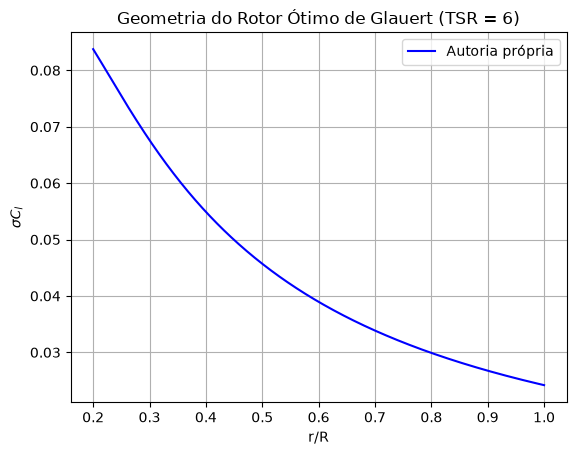

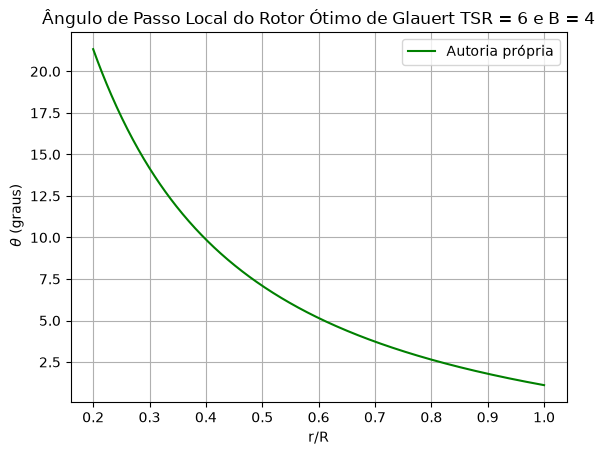

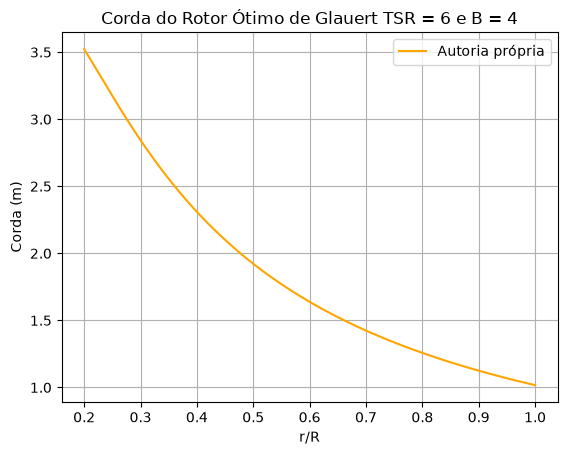

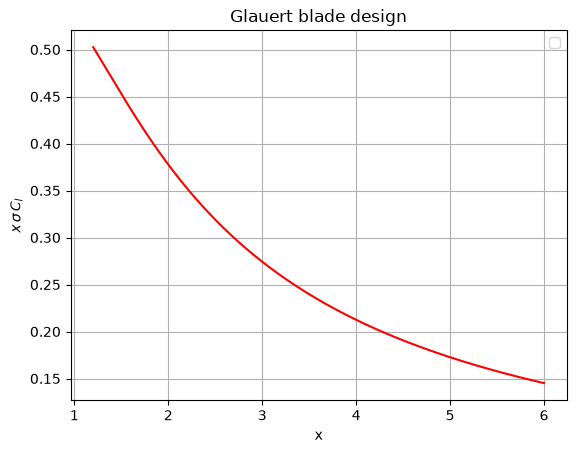

In [174]:
r = r_R * R   #posição radial dimensional (m)  
x_lista = TSR * r_R

#Grafico das validações do rotor ótimo de Glauert  pro TSR de cada Literatura  

# Sorensen – Fig. 5.2 
plt.figure()
plt.plot(r_R, r_R * sigma_lista * Cl_otimo, color='blue', label=f'Autoria própria')
plt.xlabel('r/R')
plt.ylabel(r'$\sigma C_l$')
plt.title(f'Geometria do Rotor Ótimo de Glauert (TSR = {TSR})')
plt.legend(); plt.grid() 

#sorensen – Fig. 5.3 
plt.figure() 
plt.plot(r_R, theta, color='green', label='Autoria própria') 
plt.xlabel('r/R')
plt.ylabel(r' $\theta$ (graus)')
plt.title(f'Ângulo de Passo Local do Rotor Ótimo de Glauert TSR = {TSR} e B = {B}')
plt.legend(); plt.grid() 

plt.figure() 
plt.plot(r_R, c_lista, color='orange', label=f'Autoria própria') 
plt.xlabel('r/R')
plt.ylabel('Corda (m)')
plt.title(f'Corda do Rotor Ótimo de Glauert TSR = {TSR} e B = {B}')
plt.legend(); plt.grid()

# Schaffarczyk – Fig. 5.6 
plt.figure()
plt.plot(x_lista, x_lista * sigma_lista * Cl_otimo, color='red')
plt.xlabel('x')
plt.ylabel(r'$x\,\sigma\,C_l$')
plt.title('Glauert blade design')
plt.legend(); plt.grid() 






#Grafico 

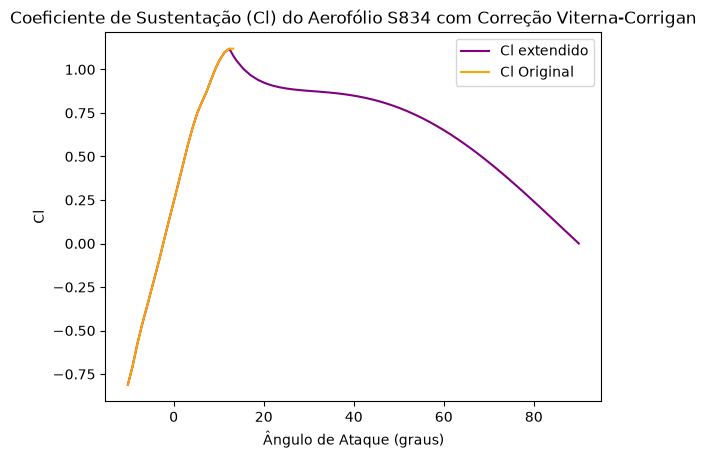

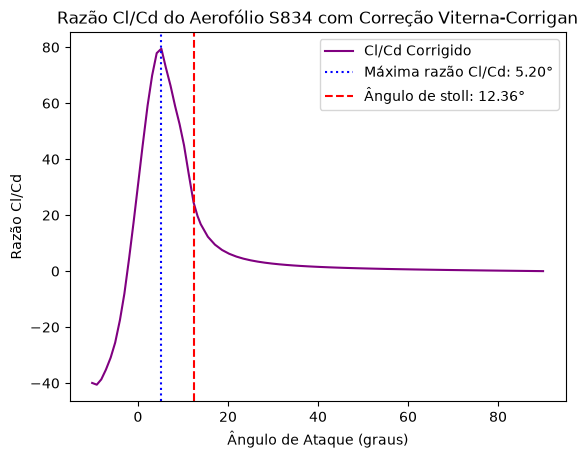

In [175]:

#Correção para altos angulos de ataque (Viterna-Corrigan)
AR = R / corda_75  #Correção para esbeltez a 75% da corda

Cd_max = 1.11 + 0.018 * AR #Correção pro Cd Maximo pra um angulo de alpha = 90 graus
B_1 = Cd_max

if AR <= 50:
    A_1 = Cd_max / 2
else:
    Cd_max = 1.11 + 0.018 * 50   #Cd_max fica constante para AR > 50 (= 2.01)
    B_1 = Cd_max
    A_1 = B_1 / 2

idx_stall = dados_S834['Cl'].idxmax() 
alpha_s_deg = dados_S834.loc[idx_stall, 'alpha']
Cl_s = dados_S834.loc[idx_stall, 'Cl']
Cd_s = dados_S834.loc[idx_stall, 'Cd']

alpha_sen_cl_max = np.sin(np.radians(alpha_s_deg))
alpha_cos_cl_max = np.cos(np.radians(alpha_s_deg))

A_2 = (Cl_s - (Cd_max * alpha_sen_cl_max * alpha_cos_cl_max)) * (alpha_sen_cl_max / alpha_cos_cl_max ** 2) # Ajuste para o coeficiente de sustentação máximo
B_2 = (Cd_s - (Cd_max * alpha_sen_cl_max ** 2)) / alpha_cos_cl_max  # Ajuste para o coeficiente de arrasto  

alpha_s = np.linspace(alpha_s_deg, 90, 50)  # Faixa de ângulos pós-stall até 90 graus

alpha_corrigido = np.concatenate([dados_S834['alpha'].values, alpha_s])   #lista pra armazenar ja com o alpha corrigido 
ordem = np.argsort(alpha_corrigido)   #ordena os angulos
alpha_corrigido = alpha_corrigido[ordem]

Cl_vit = []
Cd_vit = []  



for i in range(len(alpha_corrigido)):
    if alpha_corrigido[i] <= alpha_s_deg:
        Cl_vit.append(dados_S834.loc[dados_S834['alpha'] == alpha_corrigido[i], 'Cl'].values[0])
        Cd_vit.append(dados_S834.loc[dados_S834['alpha'] == alpha_corrigido[i], 'Cd'].values[0])
    else:
        Cl_vit.append(A_1 * np.sin(2 * np.radians(alpha_corrigido[i])) + A_2 * (np.cos(np.radians(alpha_corrigido[i]))**2) / np.sin(np.radians(alpha_corrigido[i])))
        Cd_vit.append(B_1 * (np.sin(np.radians(alpha_corrigido[i]))**2) + B_2 * (np.cos(np.radians(alpha_corrigido[i])))) 

Cl_vit = np.array(Cl_vit)
Cd_vit = np.array(Cd_vit)  

#pegando o alpha do ponto de máxima razão Cl/Cd após a correção 
razao_cl_cd_corrigido = np.array(Cl_vit) / np.array(Cd_vit)
idx_max = np.argmax(razao_cl_cd_corrigido)
alpha_max = alpha_corrigido[idx_max]
maximo_cl_cd = razao_cl_cd_corrigido[idx_max]


plt.figure()
plt.plot(alpha_corrigido, Cl_vit, label='Cl extendido', color='purple')
plt.plot(dados_S834['alpha'], dados_S834['Cl'], label='Cl Original', color='orange')
#plt.axvline(x=alpha_s_deg,color='red',linestyle='--',label=f'Ângulo de stall: {alpha_s_deg:.2f}°')
plt.title(f'Coeficiente de Sustentação (Cl) do Aerofólio S834 com Correção Viterna-Corrigan')
plt.xlabel('Ângulo de Ataque (graus)')
plt.ylabel('Cl')
plt.legend()   


plt.figure() 
plt.plot(alpha_corrigido, razao_cl_cd_corrigido, label='Cl/Cd Corrigido', color='purple') 
plt.axvline(x=alpha_max, color='blue', linestyle=':', label=f'Máxima razão Cl/Cd: {alpha_max:.2f}°')
plt.axvline(x=alpha_s_deg, color='red', linestyle='--', label=f'Ângulo de stoll: {alpha_s_deg:.2f}°')
plt.title(f'Razão Cl/Cd do Aerofólio S834 com Correção Viterna-Corrigan')
plt.xlabel('Ângulo de Ataque (graus)')
plt.ylabel('Razão Cl/Cd') 
plt.legend()





In [176]:

#interpolando os valores pra cada alpha corrigido 
f_cl = sp.interpolate.interp1d(alpha_corrigido, Cl_vit)   
f_cd = sp.interpolate.interp1d(alpha_corrigido, Cd_vit)   

alpha_min, alpha_max = alpha_corrigido.min(), alpha_corrigido.max()   
alpha_0 = np.interp(0, dados_S834['Cl'], dados_S834['alpha'])  #ângulo de sustentação nula (graus)

In [177]:
  

#Criação as funções do BEM para a turbina eólica com e sem correção de Ponta de pá de Prandtl e com correção de Glauert
def bem_turbina_eolica(R, B, c, theta, r, V_0, omega):
    a_lista = []
    a_linha_lista = []
    pN_lista = []
    pT_lista = [] 
    alpha_lista = []    

    for k in range(len(r)):  #Iteração ao longo da pá da turbina eólica 
        a , a_linha = 1/3 , 0  #Valores iniciais para os fatores de indução axial e tangencial  
        for n in range(100):  #Número de iterações para convergência 
            #Método BEM (Blade Element Method) para uma Turbina Eólica 

            phi = np.arctan2((1 - a) * V_0, (1 + a_linha) * omega * r[k])   #Angulo da corrente de vento relativo (em rad)
            alpha = phi - np.radians(theta[k])  #Ângulo de ataque efetivo (em radianos)  

            
            alpha_deg = np.clip(np.degrees(alpha), alpha_min, alpha_max)   #trava alpha na faixa da tabela
            Cl_local = f_cl(alpha_deg)   #interpola a polar pro angulo desejado 
            Cd_local = f_cd(alpha_deg) 

            #Implementando a correção para 3D do Hansen 
            a_coef = 2.2 
            h_coef = 1 
            n_coef = 4 
            fator_3D = min(a_coef * (c[k] / r[k])**h_coef * np.cos(np.radians(theta[k]))**n_coef, 1)
            
            Cl_inv = 2 * np.pi * (alpha - np.radians(alpha_0))
            Cl_3D = Cl_local + fator_3D * (Cl_inv - Cl_local)
            Cd_3D = Cd_local + fator_3D * (Cd_local - Cd_min)

            C_n = Cl_3D * np.cos(phi) + Cd_3D * np.sin(phi)   #Coeficiente normal ao plano do rotor
            C_t = Cl_3D * np.sin(phi) - Cd_3D * np.cos(phi)   #Coeficiente tangencial ao plano do rotor

            sigma = (c[k] * B) / (2 * np.pi * r[k])  #Fator de solidez da pá 
            a_novo = 1 / ((4 * np.sin(phi)**2) / (sigma * C_n) + 1)   #Fator de indução axial 
            a_linha_novo = 1 / ((4 * np.sin(phi) * np.cos(phi)) / (sigma * C_t) - 1)   #Fator de indução tangencial   

            amort = 0.5   # fator pra relaxar o loop

            if abs(a_novo - a) < 1e-6 and abs(a_linha_novo - a_linha) < 1e-6:
                a, a_linha = a_novo, a_linha_novo
                break
            else: 
                a = (1 - amort) * a + amort * a_novo
                a_linha = (1 - amort) * a_linha + amort * a_linha_novo   
        
        
        #Cálculo das forças locais (por unidade de envergadura) pra essa seção
        V_rel = (1 - a) * V_0 / np.sin(phi) 

        l = 0.5 * rho * V_rel**2 * c[k] * Cl_3D
        d = 0.5 * rho * V_rel**2 * c[k] * Cd_3D

        p_N = l * np.cos(phi) + d * np.sin(phi)
        p_T = l * np.sin(phi) - d * np.cos(phi)

        a_lista.append(a)
        a_linha_lista.append(a_linha)
        pN_lista.append(p_N)
        pT_lista.append(p_T)
        alpha_lista.append(alpha)
    return np.array(a_lista), np.array(a_linha_lista), np.array(pN_lista), np.array(pT_lista), np.array(alpha_lista)

#Criação da função do BEM para a turbina eólica com correção de Ponta de pá de Prandtl
def bem_turbina_eolica_Tipcorrection(R, B, c, theta, r, V_0, omega):
    a_lista_TC = []
    a_linha_lista_TC = []
    pN_lista_TC = []
    pT_lista_TC = [] 
    alpha_lista_TC = []    

    for k in range(len(r)):  #Iteração ao longo da pá da turbina eólica 
        a , a_linha = 1/3 , 0  #Valores iniciais para os fatores de indução axial e tangencial  
        for n in range(100):  #Número de iterações para convergência 
            #Método BEM (Blade Element Method) para uma Turbina Eólica 

            phi = np.arctan2((1 - a) * V_0, (1 + a_linha) * omega * r[k])   #Angulo da corrente de vento relativo (em rad)
            alpha = phi - np.radians(theta[k])  #Ângulo de ataque efetivo (em radianos)  

            
            alpha_deg = np.clip(np.degrees(alpha), alpha_min, alpha_max)   #trava alpha na faixa da tabela
            Cl_local = f_cl(alpha_deg)   #convertendo a polar pra graus
            Cd_local = f_cd(alpha_deg)

            #Implementando a correção para 3D do Hansen 
            a_coef = 2.2 
            h_coef = 1 
            n_coef = 4 
            fator_3D = min(a_coef * (c[k] / r[k])**h_coef * np.cos(np.radians(theta[k]))**n_coef, 1)
                        
            Cl_inv = 2 * np.pi * (alpha - np.radians(alpha_0))
            Cl_3D = Cl_local + fator_3D * (Cl_inv - Cl_local)
            Cd_3D = Cd_local + fator_3D * (Cd_local - Cd_min)
            
            C_n = Cl_3D * np.cos(phi) + Cd_3D * np.sin(phi)   #Coeficiente normal ao plano do rotor
            C_t = Cl_3D * np.sin(phi) - Cd_3D * np.cos(phi)   #Coeficiente tangencial ao plano do rotor

            #Correção de ponta de Pá de Prandtl (Tip Loss Factor) 
            f = (B / 2) * ((R - r[k]) / (r[k] * np.sin(phi)))
            F = (2 / np.pi) * np.arccos(np.clip(np.exp(-f), -1, 1)) #fator de perda de ponta de pá de Prandtl

            sigma = (c[k] * B) / (2 * np.pi * r[k])  #Fator de solidez da pá 
            a_novo = 1 / ((4 * F  * np.sin(phi)**2) / (sigma * C_n) + 1)   #Fator de indução axial  
            a_linha_novo = 1 / ((4 * F * np.sin(phi) * np.cos(phi)) / (sigma * C_t) - 1)   #Fator de indução tangencial  

            amort = 0.5   # fator pra relaxar o loop

            if abs(a_novo - a) < 1e-6 and abs(a_linha_novo - a_linha) < 1e-6:
                a, a_linha = a_novo, a_linha_novo
                break
            else: 
                a = (1 - amort) * a + amort * a_novo
                a_linha = (1 - amort) * a_linha + amort * a_linha_novo   
        
        #Cálculo das forças locais (por unidade de envergadura) pra essa seção
        V_rel = (1 - a) * V_0 / np.sin(phi) 

        l = 0.5 * rho * V_rel**2 * c[k] * Cl_3D
        d = 0.5 * rho * V_rel**2 * c[k] * Cd_3D  

        p_N = l * np.cos(phi) + d * np.sin(phi)
        p_T = l * np.sin(phi) - d * np.cos(phi)

        a_lista_TC.append(a)
        a_linha_lista_TC.append(a_linha)
        pN_lista_TC.append(p_N)
        pT_lista_TC.append(p_T)
        alpha_lista_TC.append(alpha)
    return np.array(a_lista_TC), np.array(a_linha_lista_TC), np.array(pN_lista_TC), np.array(pT_lista_TC), np.array(alpha_lista_TC) 

#Criação da função do BEM para a turbina eólica com correção de Glauert (tem uma expressão deduzida na literatura pro a)
def bem_turbina_eolica_Glauert(R, B, c, theta, r, V_0, omega): 
    a_lista_Glauert = []
    a_linha_lista_Glauert = []
    pN_lista_Glauert = []
    pT_lista_Glauert = [] 
    alpha_lista_Glauert = []    

    for k in range(len(r)):  #Iteração ao longo da pá da turbina eólica 
        a , a_linha = 1/3 , 0  #Valores iniciais para os fatores de indução axial e tangencial  
        for n in range(100):  #Número de iterações para convergência 
            #Método BEM (Blade Element Method) para uma Turbina Eólica 

            phi = np.arctan2((1 - a) * V_0, (1 + a_linha) * omega * r[k])   #Angulo da corrente de vento relativo (em rad)
            alpha = phi - np.radians(theta[k])  #Ângulo de ataque efetivo (em radianos)  

            
            alpha_deg = np.clip(np.degrees(alpha), alpha_min, alpha_max)   #trava alpha na faixa da tabela
            Cl_local = f_cl(alpha_deg)   #convertendo a polar pra graus
            Cd_local = f_cd(alpha_deg)

             #Implementando a correção para 3D do Hansen 
            a_coef = 2.2 
            h_coef = 1 
            n_coef = 4 
            fator_3D = min(a_coef * (c[k] / r[k])**h_coef * np.cos(np.radians(theta[k]))**n_coef, 1)
                                    
            Cl_inv = 2 * np.pi * (alpha - np.radians(alpha_0))
            Cl_3D = Cl_local + fator_3D * (Cl_inv - Cl_local)
            Cd_3D = Cd_local + fator_3D * (Cd_local - Cd_min)
                        
            C_n = Cl_3D * np.cos(phi) + Cd_3D * np.sin(phi)   #Coeficiente normal ao plano do rotor
            C_t = Cl_3D * np.sin(phi) - Cd_3D * np.cos(phi)   #Coeficiente tangencial ao plano do rotor

            #Correção de ponta de Pá de Prandtl (Tip Loss Factor) 
            f = (B / 2) * ((R - r[k]) / (r[k] * np.sin(phi)))
            F = (2 / np.pi) * np.arccos(np.clip(np.exp(-f), -1, 1)) #fator de perda de ponta de pá de Prandtl

            sigma = (c[k] * B) / (2 * np.pi * r[k])  #Fator de solidez da pá  
            if a <= 1/3:
                a_novo = 1 / ((4 * F * np.sin(phi)**2) / (sigma * C_n) + 1)   # regime leve (fórmula padrão) 
            else:
                K = sigma * C_n / np.sin(phi)**2
                coeffs = [3*F, -5*F - K, 4*F + 2*K, -K]
                roots = np.roots(coeffs)
                candidatos = [raiz.real for raiz in roots if abs(raiz.imag) < 1e-6 and 0 < raiz.real < 1]
                if candidatos:
                    a_novo = min(candidatos, key=lambda x: abs(x - a))  # raiz real mais próxima do a atual
                else:
                    a_novo = a  # fallback: mantém o valor anterior nessa iteração, evita crash 
            
            a_linha_novo = 1 / ((4 * F * np.sin(phi) * np.cos(phi)) / (sigma * C_t) - 1)   #Fator de indução tangencial  

            amort = 0.5   # fator pra relaxar o loop

            if abs(a_novo - a) < 1e-6 and abs(a_linha_novo - a_linha) < 1e-6:
                a, a_linha = a_novo, a_linha_novo
                break
            else: 
                a = (1 - amort) * a + amort * a_novo
                a_linha = (1 - amort) * a_linha + amort * a_linha_novo   
        
        #Cálculo das forças locais (por unidade de envergadura) pra essa seção
        V_rel = (1 - a) * V_0 / np.sin(phi) 

        l = 0.5 * rho * V_rel**2 * c[k] * Cl_3D
        d = 0.5 * rho * V_rel**2 * c[k] * Cd_3D  

        p_N = l * np.cos(phi) + d * np.sin(phi)
        p_T = l * np.sin(phi) - d * np.cos(phi)

        a_lista_Glauert.append(a)
        a_linha_lista_Glauert.append(a_linha)
        pN_lista_Glauert.append(p_N)
        pT_lista_Glauert.append(p_T)
        alpha_lista_Glauert.append(alpha)
    return np.array(a_lista_Glauert), np.array(a_linha_lista_Glauert), np.array(pN_lista_Glauert), np.array(pT_lista_Glauert), np.array(alpha_lista_Glauert)


In [178]:
#Chamando a Função do BEM 
a_r, a_linha_r, pN_r, pT_r, alpha_r = bem_turbina_eolica(R, B, c, theta, r, V_0, omega) #tupla armazena os valores de saida da função do BEM sem correção 
a_r_TC, a_linha_r_TC, pN_r_TC, pT_r_TC, alpha_r_TC = bem_turbina_eolica_Tipcorrection(R, B, c, theta, r, V_0, omega) #tupla armazena os valores de saida da função BEM com coerrção de ponta de pá
a_r_Glauert, a_linha_r_Glauert, pN_r_Glauert, pT_r_Glauert, alpha_r_Glauert = bem_turbina_eolica_Glauert(R, B, c, theta, r, V_0, omega) #tupla armazena os valores de saida da função BEM com coerrção de Glauert

#Calculo das forças e coeficientes de desempenho da turbina eólica com correção de Prandtl
T_TC = B * np.trapezoid(pN_r_TC, r) #pN_r_TC = função e r vetor = dr 
P_TC = B * omega * np.trapezoid(r * pT_r_TC, r)
C_T_TC = T_TC / (0.5 * rho * np.pi * R**2 * V_0**2)
C_P_TC = P_TC / (0.5 * rho * np.pi * R**2 * V_0**3)  

#Calculo das forças e coeficientes de desempenho da turbina eólica sem correção de Prandtl
T = B * np.trapezoid(pN_r, r) #pN_r = função e r vetor = dr 
P = B * omega * np.trapezoid(r * pT_r, r)
C_T = T / (0.5 * rho * np.pi * R**2 * V_0**2)
C_P = P / (0.5 * rho * np.pi * R**2 * V_0**3)  

#Calculo das forças e coeficientes de desempenho da turbina eólica com correção de Glauert 
T_G = B * np.trapezoid(pN_r_Glauert, r) #pN_r_TC = função e r vetor = dr 
P_G = B * omega * np.trapezoid(r * pT_r_Glauert, r)
C_T_G = T_G / (0.5 * rho * np.pi * R**2 * V_0**2)
C_P_G = P_G / (0.5 * rho * np.pi * R**2 * V_0**3) 

print(f'Resultados do BEM para a turbina eólica com correção de ponta de pá de Prandtl: C_T = {C_T_TC:.4f}, C_P = {C_P_TC:.4f}') 
print(f'Resultados do BEM para a turbina eólica sem correção de ponta de pá: C_T = {C_T:.4f}, C_P = {C_P:.4f}') 
print(f'Resultados do BEM para a turbina eólica com correção de Glauert: C_T = {C_T_G:.4f}, C_P = {C_P_G:.4f}')


Resultados do BEM para a turbina eólica com correção de ponta de pá de Prandtl: C_T = 0.8174, C_P = 0.4660
Resultados do BEM para a turbina eólica sem correção de ponta de pá: C_T = 0.8612, C_P = 0.5117
Resultados do BEM para a turbina eólica com correção de Glauert: C_T = 0.8322, C_P = 0.4758


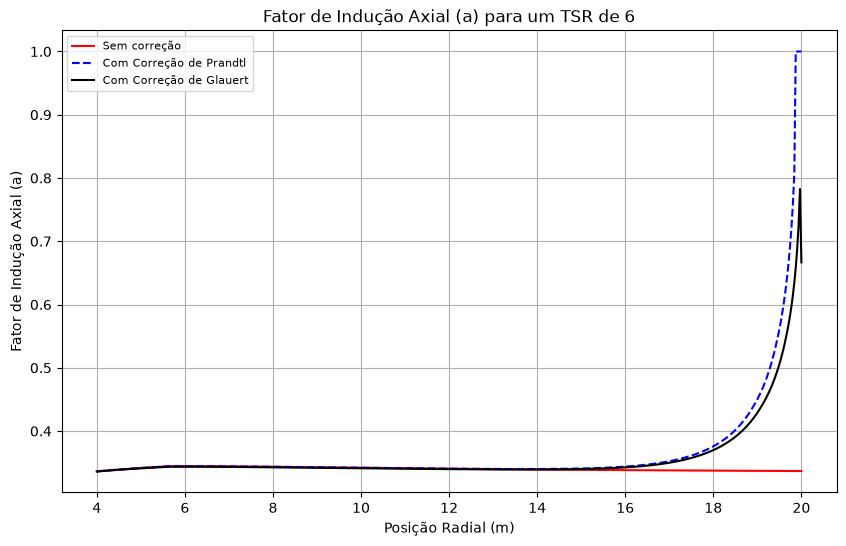

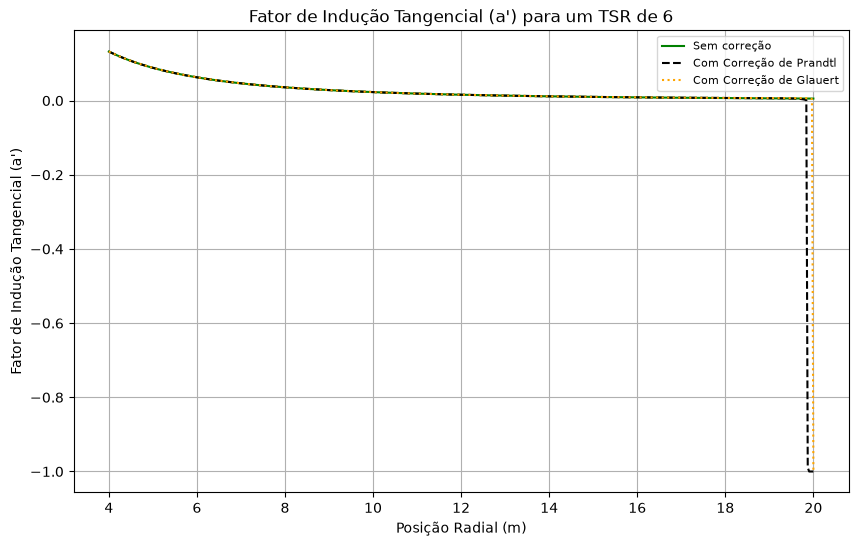

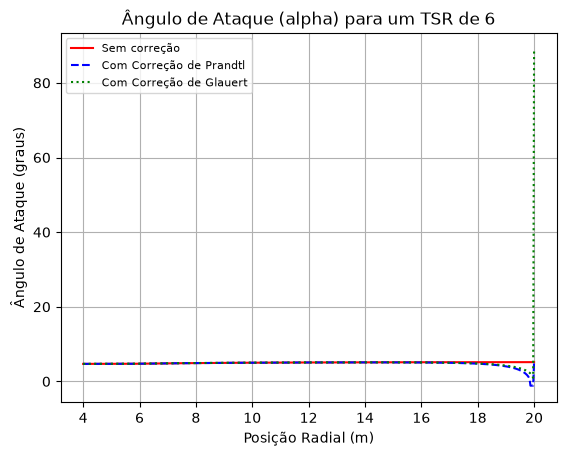

In [179]:
# fig, axs = plt.subplots(3, 2, figsize=(12, 8))


# axs[0, 0].plot(r, c, label='Distribuição de Corda', color='blue')
# axs[0, 0].set_title(f'Distribuição de Corda da Pá para um TSR de {TSR}')
# axs[0, 0].set_xlabel('Posição Radial (m)')
# axs[0, 0].set_ylabel('Corda (m)')
# axs[0, 0].legend(fontsize=8)
# axs[0, 0].grid()


# axs[0, 1].plot(r, theta, label='Distribuição de Torção', color='orange')
# axs[0, 1].set_title(f'Distribuição de Torção da Pá para um TSR de {TSR}')
# axs[0, 1].set_xlabel('Posição Radial (m)')
# axs[0, 1].set_ylabel('Torção (graus)')
# axs[0, 1].legend(fontsize=8)
# axs[0, 1].grid()


# axs[1, 0].plot(r, a_r, label='Fator de Indução Axial (a)', color='red')
# axs[1, 0].plot(r, a_r_TC, label='Com Correção de Prandtl', color='blue', linestyle='--')
# axs[1, 0].plot(r, a_r_Glauert, label='Com Correção de Glauert', color='green', linestyle=':')
# axs[1, 0].legend(fontsize=8)
# axs[1, 0].set_title(f"Fator de Indução Axial (a) para um TSR de {TSR}")
# axs[1, 0].set_xlabel('Posição Radial (m)')
# axs[1, 0].set_ylabel("Fator de Indução Axial (a)")
# axs[1, 0].grid()


# axs[1, 1].plot(r, a_linha_r, label="Fator de Indução Tangencial (a')", color='green')
# axs[1, 1].plot(r, a_linha_r_TC, label="Com Correção de Prandtl", color='purple', linestyle='--')
# axs[1, 1].plot(r, a_linha_r_Glauert, label="Com Correção de Glauert", color='orange', linestyle=':')
# axs[1, 1].legend(fontsize=8)
# axs[1, 1].set_title(f"Fator de Indução Tangencial (a') para um TSR de {TSR}")
# axs[1, 1].set_xlabel('Posição Radial (m)')
# axs[1, 1].set_ylabel("Fator de Indução Tangencial (a')")
# axs[1, 1].grid()


# axs[2, 0].plot(r, np.degrees(alpha_r), label='Sem correção', color='red')
# axs[2, 0].plot(r, np.degrees(alpha_r_TC), label='Com Correção de Prandtl', color='blue', linestyle='--')
# axs[2, 0].plot(r, np.degrees(alpha_r_Glauert), label='Com Correção de Glauert', color='green', linestyle=':')
# axs[2, 0].legend(fontsize=8)
# axs[2, 0].set_title(f'Ângulo de Ataque (alpha) para um TSR de {TSR}')
# axs[2, 0].set_xlabel('Posição Radial (m)')
# axs[2, 0].set_ylabel('Ângulo de Ataque (graus)')
# axs[2, 0].grid()


# Cp_glauert_TSR = Cp_lista[i_tsr]

# axs[2, 1].plot(TSR_lista, Cp_lista, color='green', label='Cp teórico (Glauert)')
# axs[2, 1].plot(TSR, Cp_glauert_TSR, 'go', markersize=10, label=f'Cp Glauert: {Cp_glauert_TSR:.4f}')
# axs[2, 1].plot(TSR, C_P_TC, 'rs', markersize=10, label=f'Cp BEM: {C_P_TC:.4f}')
# axs[2, 1].axhline(y=16/27, color='gray', linestyle=':', label=f'Limite de Betz: {16/27:.4f}')
# axs[2, 1].set_title(f'Cp do BEM vs Cp teórico (TSR de projeto = {TSR})')
# axs[2, 1].set_xlabel('TSR')
# axs[2, 1].set_ylabel('Cp')
# axs[2, 1].legend(fontsize=8)
# axs[2, 1].grid()

# plt.tight_layout()
# plt.show() 



plt.figure(figsize=(10, 6))
plt.plot(r, a_r, label='Sem correção', color='red')
plt.plot(r, a_r_TC, label='Com Correção de Prandtl', color='blue', linestyle='--')
plt.plot(r, a_r_Glauert, label='Com Correção de Glauert', color='black')
plt.title(f"Fator de Indução Axial (a) para um TSR de {TSR}")
plt.xlabel('Posição Radial (m)')
plt.ylabel("Fator de Indução Axial (a)")
plt.legend(fontsize=8)
plt.grid()


plt.figure(figsize=(10, 6))
plt.plot(r, a_linha_r, label="Sem correção", color='green')
plt.plot(r, a_linha_r_TC, label="Com Correção de Prandtl", color='black', linestyle='--')
plt.plot(r, a_linha_r_Glauert, label="Com Correção de Glauert", color='orange', linestyle=':')
plt.title(f"Fator de Indução Tangencial (a') para um TSR de {TSR}")
plt.xlabel('Posição Radial (m)')
plt.ylabel("Fator de Indução Tangencial (a')")
plt.legend(fontsize=8)
plt.grid()

plt.figure()
plt.plot(r, np.degrees(alpha_r), label='Sem correção', color='red')
plt.plot(r, np.degrees(alpha_r_TC), label='Com Correção de Prandtl', color='blue', linestyle='--')
plt.plot(r, np.degrees(alpha_r_Glauert), label='Com Correção de Glauert', color='green', linestyle=':')
plt.title(f'Ângulo de Ataque (alpha) para um TSR de {TSR}')
plt.xlabel('Posição Radial (m)')
plt.ylabel('Ângulo de Ataque (graus)')
plt.legend(fontsize=8)
plt.grid()




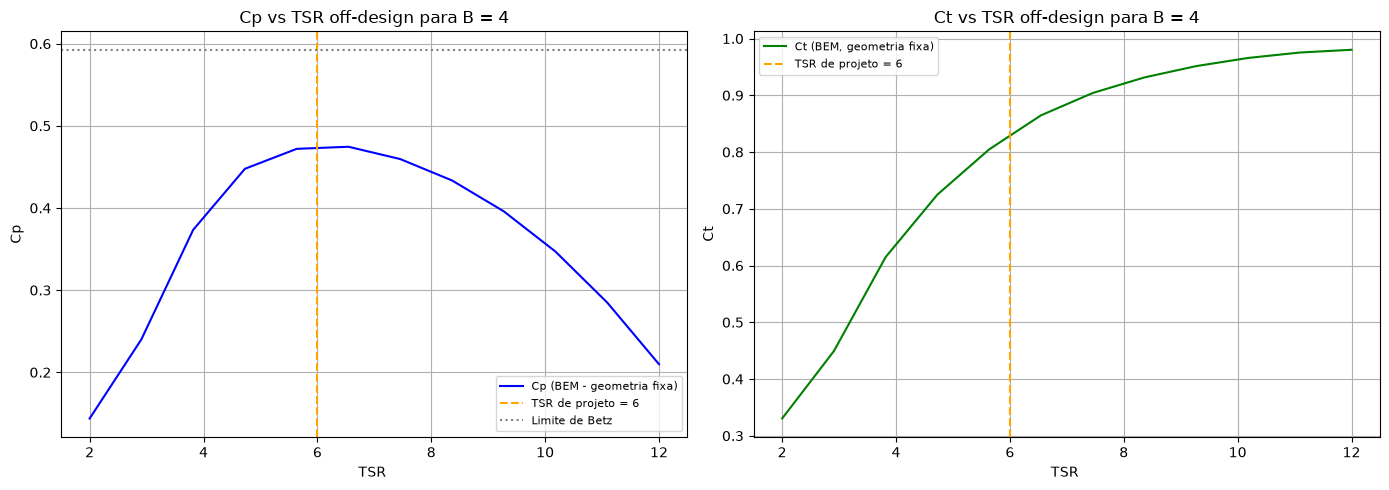

In [180]:
#Analise de Off-Design para a Geometria da pá projetada 
TSR_offdesign = np.linspace(2, 12, 12)  #Tip Speed Ratio 

C_P_offdesign = []
C_T_offdesign = [] 

for TSR_op in TSR_offdesign:
    omega_op = TSR_op * V_0 / R   #omega pra cada valor de TSR off-design

    a_r_op, a_linha_r_op, pN_r_op, pT_r_op, alpha_r_op = bem_turbina_eolica_Glauert(R, B, c, theta, r, V_0, omega_op)

    T_op = B * np.trapezoid(pN_r_op, r)
    P_op = B * omega_op * np.trapezoid(r * pT_r_op, r)

    C_P_op = P_op / (0.5 * rho * np.pi * R**2 * V_0**3)
    C_T_op = T_op / (0.5 * rho * np.pi * R**2 * V_0**2)

    C_P_offdesign.append(C_P_op)
    C_T_offdesign.append(C_T_op)

C_P_offdesign = np.array(C_P_offdesign)
C_T_offdesign = np.array(C_T_offdesign)

idx_max_offdesign = np.argmax(C_P_offdesign)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(TSR_offdesign, C_P_offdesign, color='blue', label='Cp (BEM - geometria fixa)')
axs[0].axvline(x=TSR, color='orange', linestyle='--', label=f'TSR de projeto = {TSR}')
axs[0].axhline(y=16/27, color='gray', linestyle=':', label='Limite de Betz')
axs[0].set_title(f'Cp vs TSR off-design para B = {B}')
axs[0].set_xlabel('TSR ')
axs[0].set_ylabel('Cp')
axs[0].legend(fontsize=8)
axs[0].grid()

axs[1].plot(TSR_offdesign, C_T_offdesign, color='green', label='Ct (BEM, geometria fixa)')
axs[1].axvline(x=TSR, color='orange', linestyle='--', label=f'TSR de projeto = {TSR}')
axs[1].set_title(f'Ct vs TSR off-design para B = {B}')
axs[1].set_xlabel('TSR ')
axs[1].set_ylabel('Ct')
axs[1].legend(fontsize=8)
axs[1].grid()

plt.tight_layout()
plt.show()

